# Data Prep

In [1]:
import pandas as pd
df = pd.read_csv('train.csv')
calender_events =  pd.read_csv('calendar_events.csv')
df = df.merge( calender_events, on='date', how = 'left')
#df

In [2]:
#make events a binary yes or no
df['event_binary'] = df['event'].notna().astype(int)
#make features lagged
df = df.sort_values(['store_id', 'date'])

for lag in [1, 2, 7, 14, 30, 90, 60, 364]:
    df[f'lag_{lag}'] = df.groupby('store_id')['revenue'].shift(lag)
    window = lag
    df[f'rolling_std_{window}']  = df.groupby('store_id')['revenue'].transform(
        lambda x: x.shift(1).rolling(window).std())


df['momentum_7']  = df['lag_7']  - df['lag_14']   # need lag_14
df['momentum_30'] = df['lag_30'] - df['lag_60'] 

#features day of week and month 
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month


FEATURES = ['event_binary', 'lag_1', 'lag_2', 'day_of_week', 'month','lag_7' ,'lag_30', 'lag_90' , 'momentum_7', 'momentum_30',  'rolling_std_7', 'rolling_std_30','lag_364']


# #tomorrws revenue
# df['target_daily'] = df.groupby('store_id')['revenue'].shift(-1)
# #todays revenue 
# df['target_monthly'] = df.groupby('store_id')['revenue'].shift(-30)
# df
# 


In [43]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
def train_test_split_90(store_df):
    store_df = store_df.sort_values('date').reset_index(drop=True)
    test  = store_df.tail(90)        # last 90 rows regardless of calendar gaps
    train = store_df.iloc[:-90]
    split_date = train['date'].max()
    return train, test, split_date

# ── 3. HORIZON-SHIFTED TRAINING DATA ────────────────────────────────────────

def make_horizon_df(store_df, horizon):
    """
    Target becomes revenue `horizon` days into the future.
    Features are the same lagged features from the current row.
    """
    d = store_df.copy()
    d['target'] = d['revenue'].shift(-horizon)
    return d.dropna(subset=FEATURES + ['target'])

# ── 4. RECURSIVE PREDICTION HELPERS ─────────────────────────────────────────
def make_future_row(pred_date, last_known, event_calendar):
    def get_lag(n):
        return last_known.get(pred_date - pd.Timedelta(days=n), np.nan)

    recent_vals = [last_known.get(pred_date - pd.Timedelta(days=k), np.nan) for k in range(1, 8)]

    return {
        'date':             pred_date,
        'event_binary':     event_calendar.get(pred_date, 0),
        'days_since_event': 0,  # simplified for future dates
        'lag_1':            get_lag(1),
        'lag_2':            get_lag(2),
        'lag_7':            get_lag(7),
        # 'lag_14':           get_lag(14),
        'lag_30':           get_lag(30),
        # 'lag_60':           get_lag(60),
        'lag_90':           get_lag(90),
        'lag_364':          get_lag(364),
        # 'rolling_mean_7':   np.nanmean(recent_vals),
        # 'rolling_mean_14':  np.nanmean([last_known.get(pred_date - pd.Timedelta(days=k), np.nan) for k in range(1, 15)]),
        # 'rolling_mean_30':  np.nanmean([last_known.get(pred_date - pd.Timedelta(days=k), np.nan) for k in range(1, 31)]),
        'rolling_std_7':    np.nanstd(recent_vals),
        'rolling_std_30':   np.nanstd([last_known.get(pred_date - pd.Timedelta(days=k), np.nan) for k in range(1, 31)]),
        'momentum_7':       get_lag(7)  - get_lag(14),
        'momentum_30':      get_lag(30) - get_lag(60),
        'day_of_week':      pred_date.dayofweek,
        'is_weekend':       int(pred_date.dayofweek >= 5),
        'month':            pred_date.month,
        'week_of_year':     pred_date.isocalendar()[1],
    }

def recursive_predict(model, horizon_days, last_known, start_date, event_calendar):
    preds   = []
    running = dict(last_known)

    for i in range(horizon_days):
        pred_date = start_date + pd.Timedelta(days=i)
        row       = make_future_row(pred_date, running, event_calendar)
        X         = pd.DataFrame([row])[FEATURES]
        y_hat     = model.predict(X)[0]
        running[pred_date] = y_hat
        preds.append((pred_date, y_hat))

    return preds


def recursive_predict_chunked(model, total_days, chunk_size, last_known,
                               start_date, event_calendar):
    """
    Predict in blocks of chunk_size days.
    Each completed chunk is written back to running before the next chunk starts.
    Daily  (chunk=1)  → predicts 1 day, feeds back, repeats
    Monthly(chunk=30) → predicts 30 days, feeds back whole block, repeats
    Quarterly(chunk=90)→ predicts all 90 days in one shot
    """
    all_preds     = []
    running       = dict(last_known)
    current_start = start_date
    days_left     = total_days

    while days_left > 0:
        chunk       = min(chunk_size, days_left)
        chunk_preds = recursive_predict(model, chunk, running,
                                        current_start, event_calendar)
        for date, val in chunk_preds:
            running[date] = val
        all_preds.extend(chunk_preds)
        current_start += pd.Timedelta(days=chunk)
        days_left     -= chunk

    return all_preds

# ── 5. TRAIN 3 MODELS PER STORE & EVALUATE ──────────────────────────────────

# XGB_PARAMS = dict(
#     n_estimators    = 300,
#     learning_rate   = 0.05,
#     max_depth       = 6,
#     subsample       = 0.8,
#     colsample_bytree= 0.8,
#     random_state    = 42,
#     n_jobs          = -1,
# )
# XGB_PARAMS = dict(
#     n_estimators=300,
#     learning_rate=0.05,
#     max_depth=3,        # was 6 — shallower trees generalise better
#     subsample=0.8,
#     colsample_bytree=0.8,
#     reg_alpha=1.0,      # L1 regularisation
#     reg_lambda=5.0,     # L2 regularisation
# )
XGB_PARAMS = dict(
    # --- 1. The M5 Tweedie Objective ---
    objective='reg:tweedie',
    tweedie_variance_power=1.1,   # The M5 "Magic Number" for unit sales
    
    # --- 2. Hardware & Memory Management ---
    tree_method='hist',           # CRITICAL: Use 'gpu_hist' if you have a GPU
    max_bin=100,                  # Lowered from default 256. Saves massive RAM with almost no accuracy loss
    
    # --- 3. Tree Architecture (Complexity vs Overfitting) ---
    max_depth=8,                  # Deeper than standard to capture 3-way/4-way calendar interactions
    min_child_weight=100,         # High threshold to prevent overfitting on sparse, low-volume items
    
    # --- 4. Learning & Sampling ---
    learning_rate=0.03,           # Slower learning rate (requires more estimators, but yields better generalisation)
    subsample=0.7,                # Randomly drops 30% of rows per tree to prevent overfitting
    colsample_bytree=0.7,         # Randomly drops 30% of features per tree to force feature diversity
    
    # --- 5. Regularization ---
    reg_lambda=0.1,               # L2 regularization on leaf weights
    reg_alpha=0.1,
    
)
store_models  = {}  # {store_name: {'daily': model, 'monthly': model, 'quarterly': model}}
store_results = {}  # {store_name: {'daily': df, 'monthly': df, 'quarterly': df}}

MODEL_CONFIGS = [
    ('daily',     1,  1),   # (name, training horizon, prediction chunk size)
    ('monthly',  30, 30),
    ('quarterly',90, 90),
]

for store_name, group in df.groupby('store_name'):
    group      = group.sort_values('date').reset_index(drop=True)
    train_df, test_df, split_date = train_test_split_90(group)

    last_known = dict(zip(train_df['date'], train_df['revenue']))
    event_cal  = dict(zip(group['date'],    group['event_binary']))
    test_start = test_df['date'].min()

    print(f"\n{'='*65}")
    print(f"Store : {store_name}")
    print(f"Train : up to {split_date.date()}  |  "
          f"Test  : {test_start.date()} → {test_df['date'].max().date()}  "
          f"({len(test_df)} rows)")

    models  = {}
    results = {}

    for model_name, train_horizon, chunk_size in MODEL_CONFIGS:

        # Each model trained to predict a different horizon ahead
        train_h = make_horizon_df(train_df, train_horizon)
        X_train = train_h[FEATURES]
        y_train = train_h['target']

        model = XGBRegressor(**XGB_PARAMS)
        model.fit(X_train, y_train, verbose=False)

        # All 3 models predict the same 90-day test window
        preds = recursive_predict_chunked(
            model          = model,
            total_days     = 90,
            chunk_size     = chunk_size,
            last_known     = last_known,
            start_date     = test_start,
            event_calendar = event_cal,
        )

        pred_df = pd.DataFrame(preds, columns=['date', 'pred_revenue'])
        merged  = test_df[['date', 'revenue']].merge(pred_df, on='date', how='inner')

        mae  = mean_absolute_error(merged['revenue'], merged['pred_revenue'])
        rmse = mean_squared_error(merged['revenue'],  merged['pred_revenue']) ** 0.5
        mape = (((merged['revenue'] - merged['pred_revenue']).abs()
                 / merged['revenue'].replace(0, np.nan)).mean()) * 100

        print(f"  [{model_name:>10}]  "
              f"MAE={mae:>10,.0f}   RMSE={rmse:>10,.0f}   MAPE={mape:>6.1f}%")

        models[model_name]  = model
        results[model_name] = pred_df

    store_models[store_name]  = models
    store_results[store_name] = results

print(f"\n{'='*65}")
print("Done. Outputs:")
print("  store_models  → {store_name: {'daily', 'monthly', 'quarterly'}}")
print("  store_results → {store_name: {'daily', 'monthly', 'quarterly'}} (pred DataFrames)")



Store : All Stores
Train : up to 2015-07-02  |  Test  : 2015-07-03 → 2015-09-30  (90 rows)
  [     daily]  MAE=    31,988   RMSE=    42,080   MAPE=  10.0%
  [   monthly]  MAE=    45,568   RMSE=    58,279   MAPE=  14.3%
  [ quarterly]  MAE=    50,758   RMSE=    63,498   MAPE=  15.8%

Store : California – Golden Hills
Train : up to 2015-07-02  |  Test  : 2015-07-03 → 2015-09-30  (90 rows)
  [     daily]  MAE=     5,128   RMSE=     6,661   MAPE=   9.8%
  [   monthly]  MAE=     8,494   RMSE=    10,039   MAPE=  16.3%
  [ quarterly]  MAE=    13,059   RMSE=    15,667   MAPE=  24.5%

Store : California – Ocean View
Train : up to 2015-07-02  |  Test  : 2015-07-03 → 2015-09-30  (90 rows)
  [     daily]  MAE=     8,841   RMSE=    11,612   MAPE=  25.1%
  [   monthly]  MAE=     9,978   RMSE=    13,287   MAPE=  27.6%
  [ quarterly]  MAE=    11,206   RMSE=    13,651   MAPE=  32.4%

Store : California – Redwood Center
Train : up to 2015-07-02  |  Test  : 2015-07-03 → 2015-09-30  (90 rows)
  [     dai

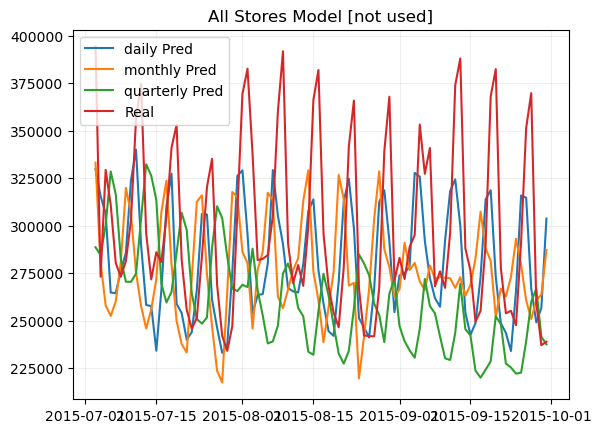

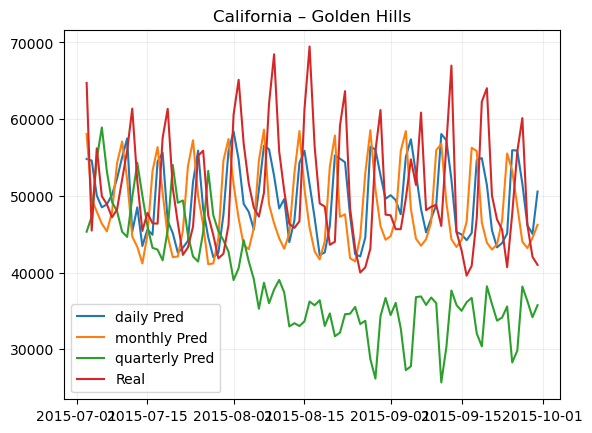

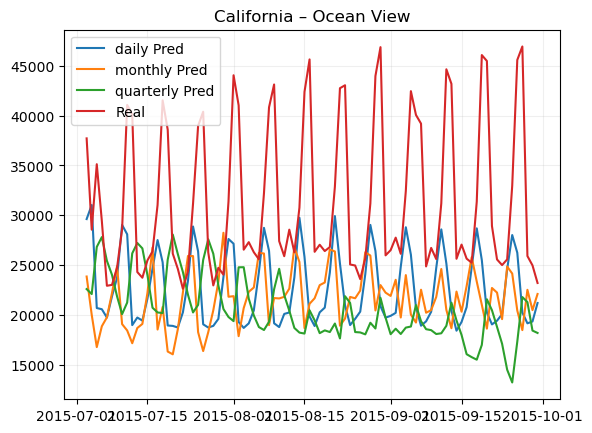

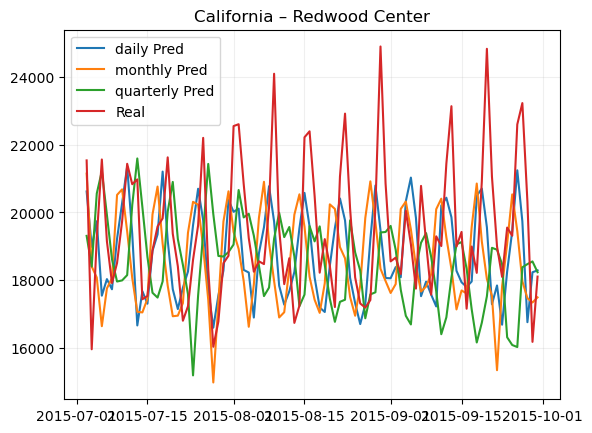

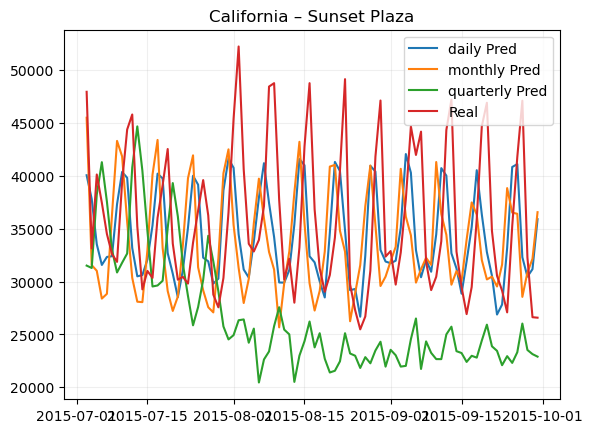

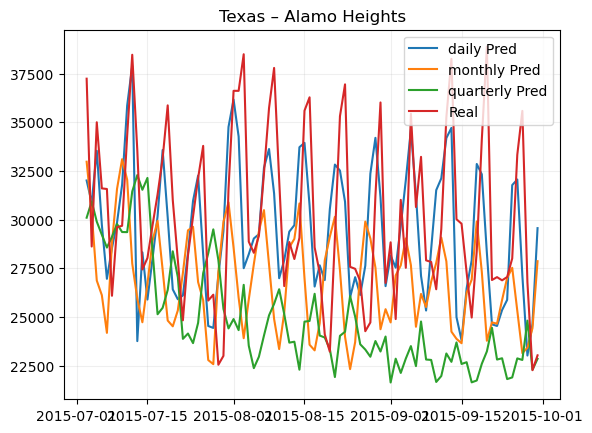

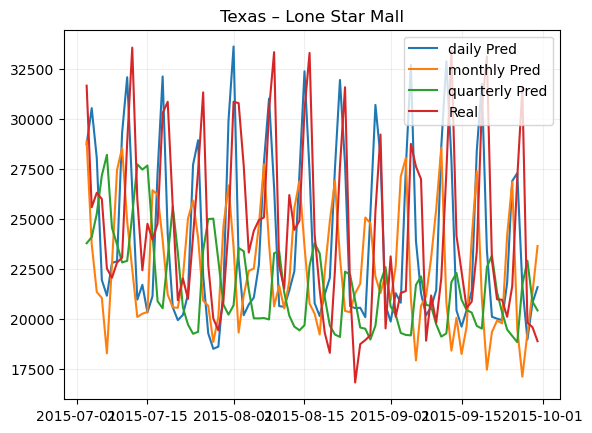

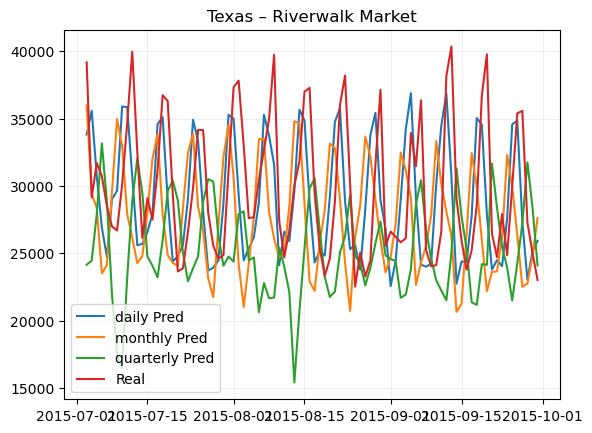

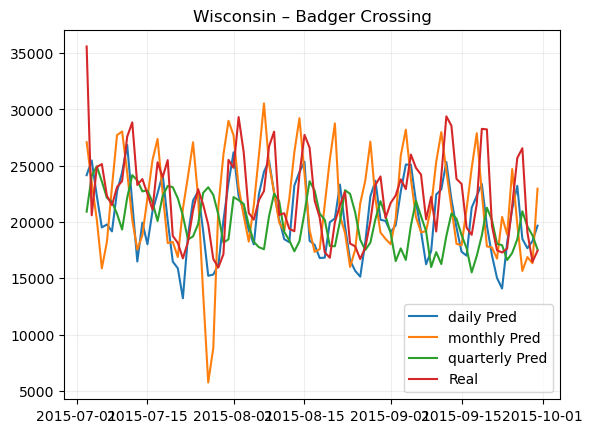

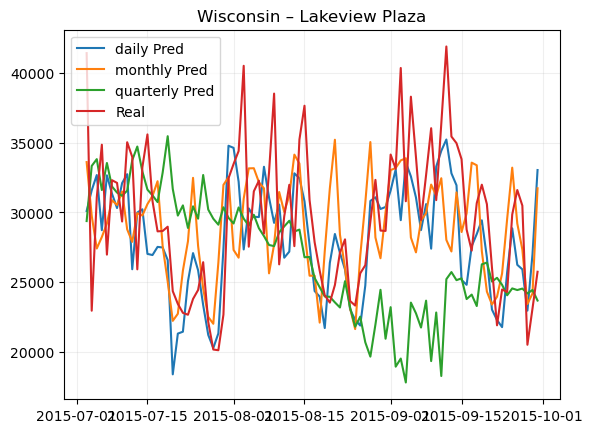

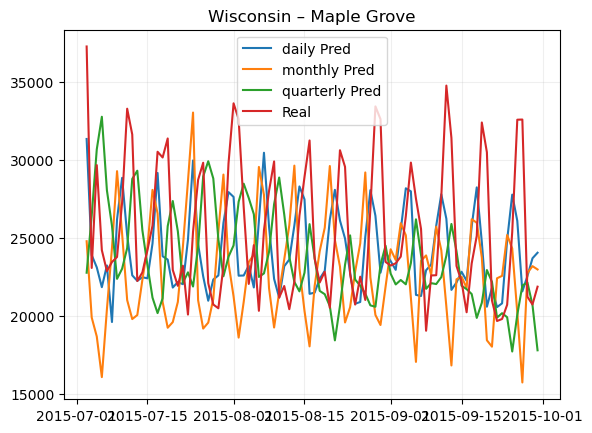

In [56]:
import matplotlib.pyplot as plt

# train, test_df, date = train_test_split_90(df)
# print(test_df[test_df['store_name'] == 'All Stores']['date'])

for store in store_results:
    
    train, test_df, date = train_test_split_90(df[df['store_name'] == store])
    if store == 'All Stores': 
        plt.title('All Stores Model [not used]')
    else:
        plt.title(store)
    pred = store_results[store]
    
    for period in pred:
        plt.plot(pred[period]['date'], pred[period]['pred_revenue'], label = f'{period} Pred')
        # break
    plt.grid(alpha = 0.2)
    
    # print(test_df[test_df['store_name'] == store]['date'])
    plt.plot(test_df[test_df['store_name'] == store]['date'], test_df[test_df['store_name'] == store]['revenue'], label = 'Real')
    plt.legend()
    plt.show()
    


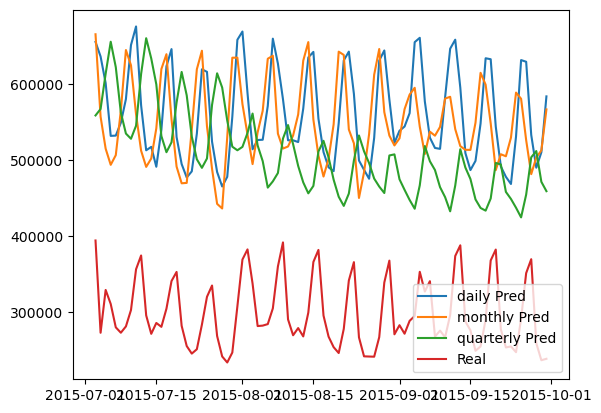

In [59]:
all_preds = {}
for model_name in ['daily', 'monthly', 'quarterly']:
    combined = (pd.concat([store_results[s][model_name] 
                           for s in store_results])
                  .groupby('date')['pred_revenue']
                  .sum()
                  .reset_index())
    all_preds[model_name] = combined

# all_preds
train, test_df, date = train_test_split_90(df[df['store_name'] == 'All Stores'])

for period in all_preds:
    plt.plot(all_preds[period]['date'], all_preds[period]['pred_revenue'], label = f'{period} Pred')
plt.plot(test_df[test_df['store_name']== 'All Stores']['date'], test_df[test_df['store_name']== 'All Stores']['revenue'], label = 'Real')
plt.legend()
plt.show()

